<a href="https://colab.research.google.com/github/sevcenkolera/sevcenko/blob/main/lab3_Shevchenko.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving spotify-2023.csv to spotify-2023.csv


In [ ]:
import os
os.listdir()

['.config', 'spotify-2023.csv', 'sample_data']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю графіків (за бажанням)
sns.set_theme(style="whitegrid")

# Завантаження датасету (переконайтеся, що файл завантажено в середовище Colab)
# encoding='latin-1' потрібен, бо в назвах пісень є специфічні символи
df = pd.read_csv('spotify-2023.csv', encoding='latin-1', on_bad_lines='skip')

# Очищення даних: колонка 'streams' має бути числового типу.
# Деякі значення можуть містити помилки, тому ми їх перетворюємо (errors='coerce')
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

# Видалення рядків, де відсутня кількість прослуховувань
df = df.dropna(subset=['streams'])

# Виведемо перші 5 рядків для перевірки
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
1,LALA,Myke Towers,1.0,2023.0,3.0,23.0,1474.0,48.0,133716286.0,48.0,...,92.0,C#,Major,71.0,61.0,74.0,7.0,0.0,10.0,4.0
2,vampire,Olivia Rodrigo,1.0,2023.0,6.0,30.0,1397.0,113.0,140003974.0,94.0,...,138.0,F,Major,51.0,32.0,53.0,17.0,0.0,31.0,6.0
3,Cruel Summer,Taylor Swift,1.0,2019.0,8.0,23.0,7858.0,100.0,800840817.0,116.0,...,170.0,A,Major,55.0,58.0,72.0,11.0,0.0,11.0,15.0
4,WHERE SHE GOES,Bad Bunny,1.0,2023.0,5.0,18.0,3133.0,50.0,303236322.0,84.0,...,144.0,A,Minor,65.0,23.0,80.0,14.0,63.0,11.0,6.0
7,Columbia,Quevedo,1.0,2023.0,7.0,7.0,714.0,43.0,58149378.0,25.0,...,100.0,F,Major,67.0,26.0,71.0,37.0,0.0,11.0,4.0


/tmp/ipykernel_303/1927431353.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='streams', y='track_name', data=top_10_songs, palette='viridis')


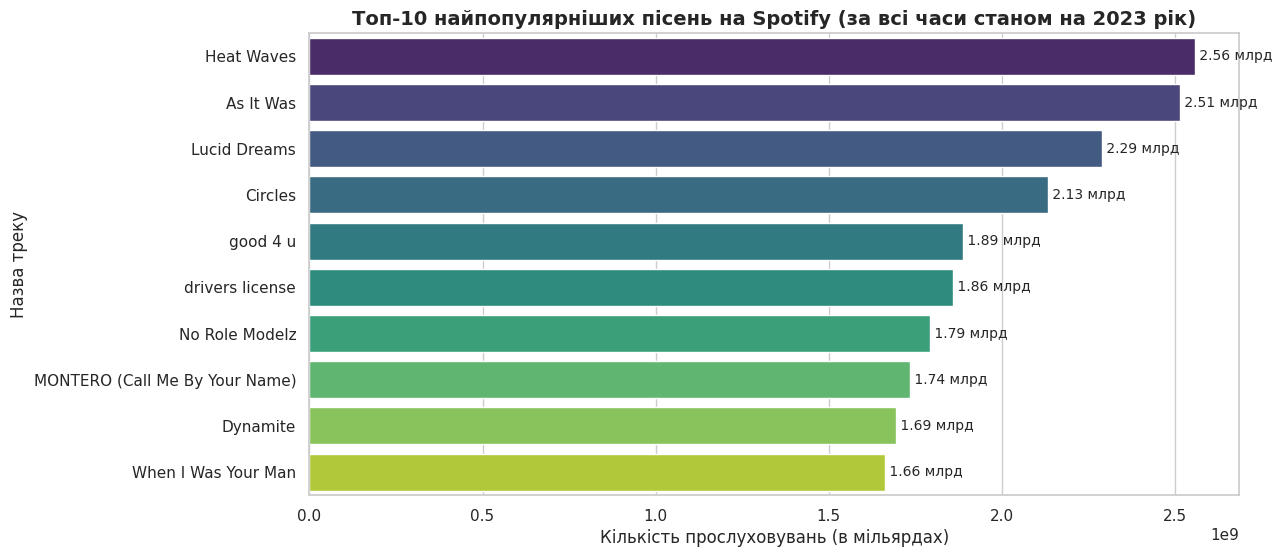

In [ ]:
# Відбираємо топ-10 пісень за кількістю стрімів
top_10_songs = df.nlargest(10, 'streams')

plt.figure(figsize=(12, 6))
sns.barplot(x='streams', y='track_name', data=top_10_songs, palette='viridis')

# Оформлення графіка
plt.title('Топ-10 найпопулярніших пісень на Spotify (за всі часи станом на 2023 рік)', fontsize=14, fontweight='bold')
plt.xlabel('Кількість прослуховувань (в мільярдах)', fontsize=12)
plt.ylabel('Назва треку', fontsize=12)

# Додавання підписів даних (опціонально)
for index, value in enumerate(top_10_songs['streams']):
    plt.text(value, index, f' {value/1e9:.2f} млрд', va='center', fontsize=10)

plt.show()

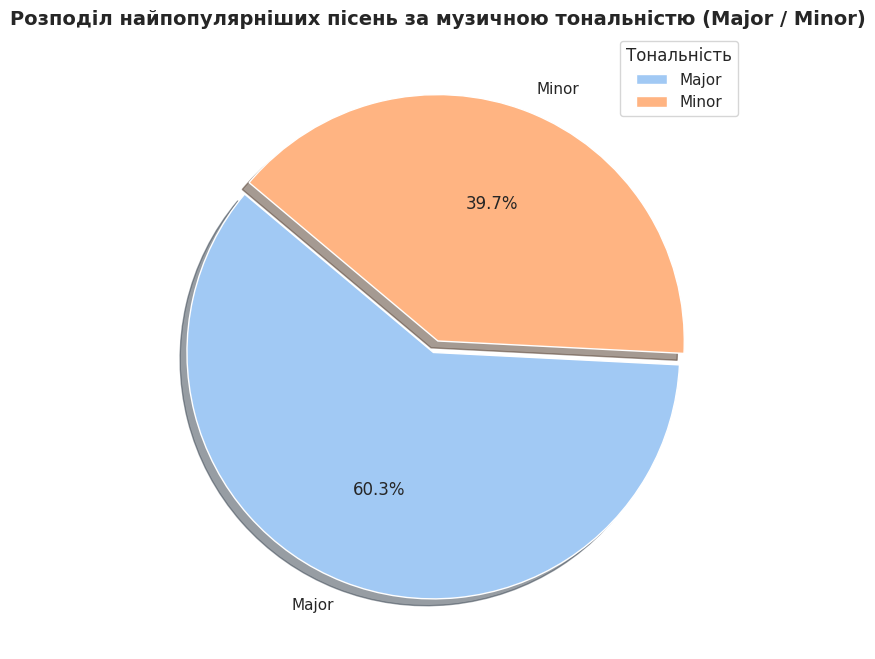

In [ ]:
# Рахуємо кількість кожної тональності
mode_counts = df['mode'].value_counts()

plt.figure(figsize=(8, 8))
# Використання matplotlib для кругової діаграми
plt.pie(mode_counts,
        labels=mode_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'),
        explode=(0.05, 0), # Трохи "витягуємо" перший сектор
        shadow=True)

plt.title('Розподіл найпопулярніших пісень за музичною тональністю (Major / Minor)', fontsize=14, fontweight='bold')
plt.legend(title="Тональність", loc="upper right")
plt.show()

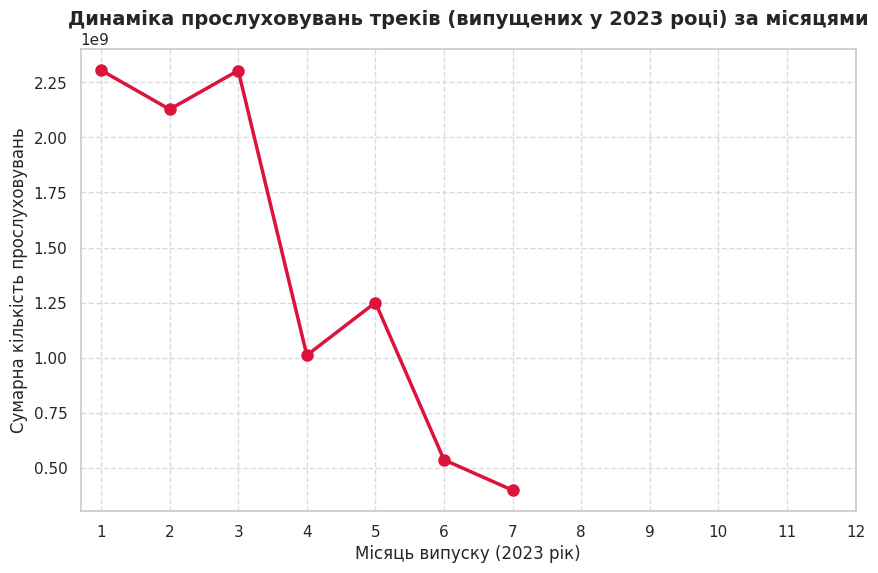

In [ ]:
# Фільтруємо треки, що вийшли лише у 2023 році
df_2023 = df[df['released_year'] == 2023]

# Групуємо за місяцями та рахуємо загальну кількість стрімів
monthly_streams = df_2023.groupby('released_month')['streams'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(monthly_streams['released_month'], monthly_streams['streams'],
         marker='o', linestyle='-', color='crimson', linewidth=2.5, markersize=8)

plt.title('Динаміка прослуховувань треків (випущених у 2023 році) за місяцями', fontsize=14, fontweight='bold')
plt.xlabel('Місяць випуску (2023 рік)', fontsize=12)
plt.ylabel('Сумарна кількість прослуховувань', fontsize=12)
plt.xticks(np.arange(1, 13)) # Вісь X від 1 до 12 місяця
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

/tmp/ipykernel_303/1603614445.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='streams', y='artist(s)_name', data=top_10_artists, palette='magma')


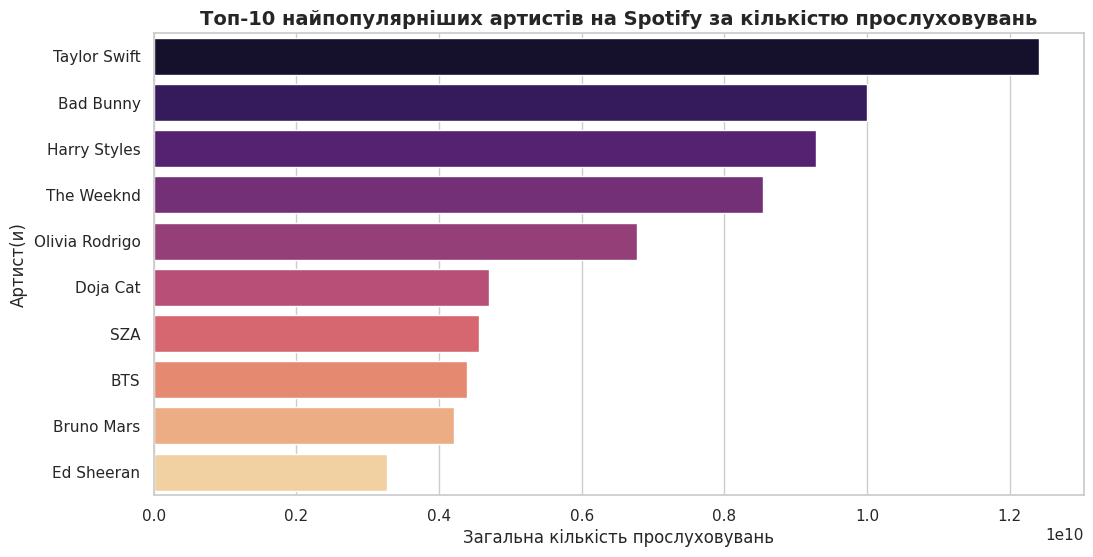

In [ ]:
# Групування за артистами
top_10_artists = df.groupby('artist(s)_name')['streams'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='streams', y='artist(s)_name', data=top_10_artists, palette='magma')

plt.title('Топ-10 найпопулярніших артистів на Spotify за кількістю прослуховувань', fontsize=14, fontweight='bold')
plt.xlabel('Загальна кількість прослуховувань', fontsize=12)
plt.ylabel('Артист(и)', fontsize=12)

plt.show()

/tmp/ipykernel_303/182291507.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='streams', y='track_name', data=df_three_tracks, palette='coolwarm')


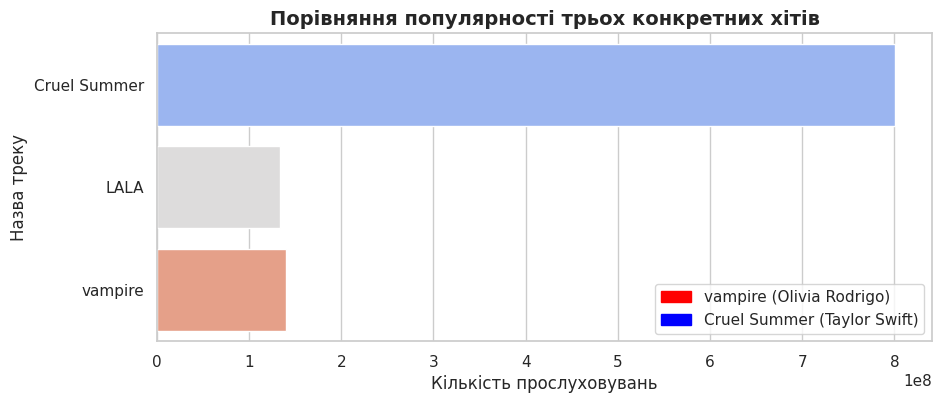

In [ ]:
# Список треків для порівняння
tracks_to_compare = ['Cruel Summer', 'vampire', 'LALA']

# Фільтрація даних за обраними треками
df_three_tracks = df[df['track_name'].isin(tracks_to_compare)]

# Якщо деякі пісні мають дублікати, візьмемо найбільше значення для кожної
df_three_tracks = df_three_tracks.groupby('track_name')['streams'].max().reset_index()

plt.figure(figsize=(10, 4))
sns.barplot(x='streams', y='track_name', data=df_three_tracks, palette='coolwarm')

plt.title('Порівняння популярності трьох конкретних хітів', fontsize=14, fontweight='bold')
plt.xlabel('Кількість прослуховувань', fontsize=12)
plt.ylabel('Назва треку', fontsize=12)

# Додаємо легенду вручну для прикладу
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='vampire (Olivia Rodrigo)')
blue_patch = mpatches.Patch(color='blue', label='Cruel Summer (Taylor Swift)')
plt.legend(handles=[red_patch, blue_patch], loc='lower right')

plt.show()